In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from dataloader import get_nd_array, get_slice
from download.hf import pull_predictions_from_hf

# Import scaling law code
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))
import ladder
plt.close()

In [ ]:
local_path = pull_predictions_from_hf("allenai/ladder-evals", "instances")

: 

In [ ]:
# Choose a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice', 'logits_per_char_corr', 'logits_per_byte_corr'] # accuracy benchmarks
COLS += ['exact_match', 'f1'] # generation benchmarks
COLS += ['pass_at_1', 'pass_at_10'] # code benchmarks

df = pd.read_parquet(local_path, columns=COLS)
print(f'Loaded {len(df):,} instance results')

In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()

In [83]:
all_ladder_models   = [model for model in MODELS if 'peteish-moreeval' in model]
data_mixes          = [model for model in MODELS if '1B-5xC' in model if 'peteish' not in model]
all_models   = sorted([model for model in MODELS if model not in data_mixes + all_ladder_models])

MODEL_1B_5xC = "peteish-moreeval-1B-5xC"

### Bradley-Terry Ranking

In [1]:
# task_name = ["arc_challenge"]
# task_name = ["arc_challenge", "arc_easy"]
task_name = [task for task in TASKS if 'mmlu' in task and ':' not in task and 'pro' not in task]
task_name = [task for task in TASKS if 'mmlu' in task and ':' not in task and 'pro' not in task and 'moral_scenarios' not in task]

NameError: name 'TASKS' is not defined

In [270]:
model_names, scores = get_nd_array(
    df,
    col=["model"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task=task_name,
    model=all_models,
    sorted=True
)

print(f'Results on {len(model_names)} models:')
print(scores)
print(scores.shape)

Results on 37 models:
[[1. 1. 0. ... 1. 0. 1.]
 [1. 1. 1. ... 1. 0. 1.]
 [1. 0. 1. ... 1. 0. 1.]
 ...
 [1. 0. 1. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 1. ... 0. 0. 1.]]
(37, 1172)


In [271]:
step_names, step_scores = get_nd_array(
    df,
    col=["step"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task=task_name,
    model=MODEL_1B_5xC,
    sorted=False
)

print(f'Results on {len(step_names)} models:')
print(step_scores)
print(step_scores.shape)

Results on 164 models:
[[0. 1. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 1. 0. 1.]]
(164, 1172)


### Fit Bradley-Terry Model

Total variation of ['arc_challenge'] training curve: [[nan 0.669392411799283]]


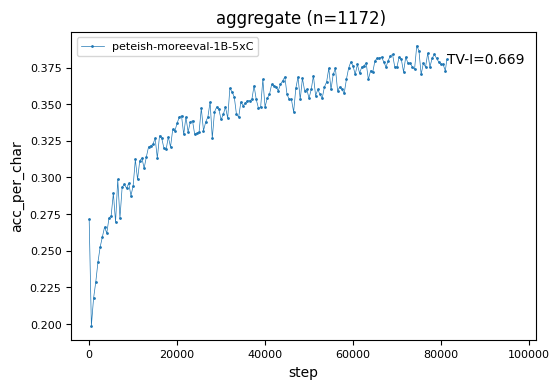

In [272]:
from stats import compute_total_variation

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

# Compute total variation across training checkpoints
tv_results, _ = compute_total_variation(
    df, 
    tasks=[task_name],
    models=[MODEL_1B_5xC],
    metric='acc_per_char',
    axes=[axes[0][0]]
)
tv = tv_results.values
print(f'Total variation of {task_name} training curve: {tv}')

In [273]:
from irt import bradley_terry_scores

train_scores, test_scores = bradley_terry_scores(train_scores=scores, test_scores=step_scores)

Computing test scores: 100%|██████████| 164/164 [00:00<00:00, 3811.04it/s]


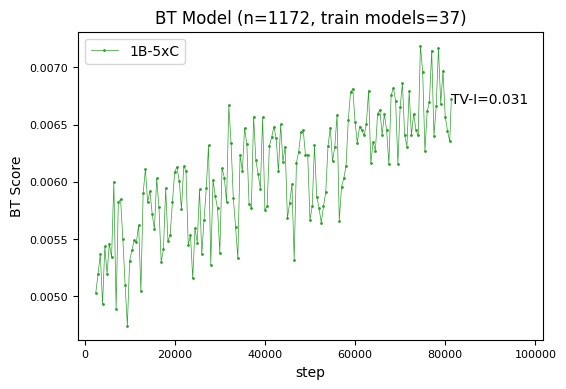

In [274]:
from plot import plot_training
from stats import calculate_and_plot_total_variation

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

_ = calculate_and_plot_total_variation(
    ax=axes[0, 0], 
    model_name="1B-5xC",
    # x=step_names, y=test_scores,
    x=step_names[5:], y=test_scores[5:],
    metric="BT Score", 
    title=f'BT Model (n={scores.shape[1]}, train models={scores.shape[0]})'
)

### Filter Test Instances

/Users/dhei/ai2/new-evals/analysis/irt.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearsonr(step_scores[:, i], total_scores)[0]


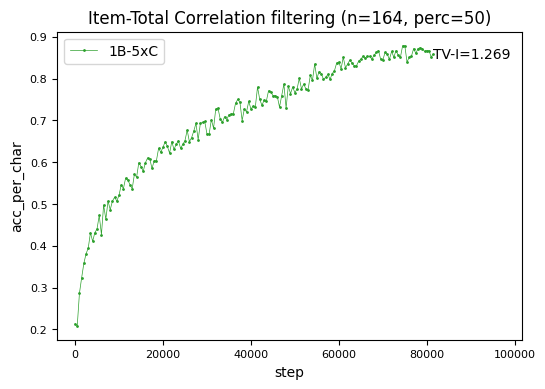

In [275]:
from irt import itc_filtering

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

PERCENTILE = 50

filtered_scores = itc_filtering(step_scores, percentile=50)

acc = filtered_scores.mean(axis=1)

tv = calculate_and_plot_total_variation(
    ax=axes[0, 0],
    model_name="1B-5xC", 
    x=step_names, y=acc,
    metric="acc_per_char",
    title=f'Item-Total Correlation filtering (n={filtered_scores.shape[0]}, perc={PERCENTILE})'
)

  0%|          | 0/19 [00:00<?, ?it/s]/Users/dhei/ai2/new-evals/analysis/irt.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearsonr(step_scores[:, i], total_scores)[0]
100%|██████████| 19/19 [00:07<00:00,  2.56it/s]


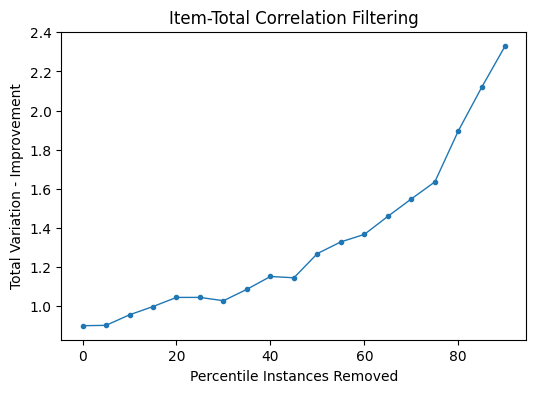

In [282]:
# Calculate TV for different percentile thresholds
percentiles = np.arange(0, 91, 5)
tvs = []
for p in tqdm(percentiles):
    filtered_scores = itc_filtering(step_scores, percentile=p)
    acc = filtered_scores.mean(axis=1)
    tv = calculate_and_plot_total_variation(
        x=step_names, y=acc,
        metric="acc_per_char",
    )
    tvs.append(tv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(percentiles, tvs, '-o', linewidth=1, markersize=3)
ax.set_xlabel('Percentile Instances Removed')
ax.set_ylabel('Total Variation - Improvement')
ax.set_title('Item-Total Correlation Filtering')
plt.show()

100%|██████████| 19/19 [00:00<00:00, 1681.30it/s]


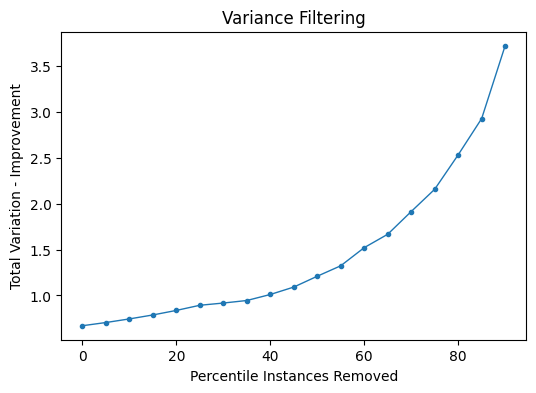

In [278]:
from irt import variance_filtering

# Calculate TV for different percentile thresholds
percentiles = np.arange(0, 91, 5)
tvs = []
for p in tqdm(percentiles):
    filtered_scores = variance_filtering(step_scores, percentile=p)
    acc = filtered_scores.mean(axis=1)
    tv = calculate_and_plot_total_variation(
        x=step_names, y=acc,
        metric="acc_per_char",
    )
    tvs.append(tv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(percentiles, tvs, '-o', linewidth=1, markersize=3)
ax.set_xlabel('Percentile Instances Removed')
ax.set_ylabel('Total Variation - Improvement')
ax.set_title('Variance Filtering')
plt.show()